# Fruit & Vegetable Disease Classifier — Final Production Notebook

Dataset: [Kaggle Fruits and Vegetables Disease](https://www.kaggle.com/datasets/muhammadkhalid/fruits-and-vegetables-disease) (28 classes, 5GB)

Strategy: ResNet50V2 + tf.data pipeline + mixed precision + 2-phase training

> Run on Kaggle (free T4) or Google Colab

## 0. Setup

In [8]:
!pip install -q matplotlib seaborn scikit-learn pillow

import os, random, warnings, json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image as PILImage
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks, mixed_precision
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

mixed_precision.set_global_policy('mixed_float16')
print(f'Precision policy: {mixed_precision.global_policy().compute_dtype}')

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

MODEL_NAME = 'ResNet50V2'

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Precision policy: float16


## 1. Config

In [15]:
DATA_DIR   = Path('/kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/Fruit And Vegetable Diseases Dataset')
TRAIN_DIR  = DATA_DIR / 'train' if (DATA_DIR / 'train').exists() else DATA_DIR
TEST_DIR   = DATA_DIR / 'test'  if (DATA_DIR / 'test').exists()  else None
MODEL_DIR  = Path('/kaggle/working/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = (128, 128)   # fine
BATCH      = 32            # ← increase from 8
EPOCHS_FE  = 10            # ← reduce from 15 (stop earlier)
EPOCHS_FT  = 6             # ← reduce from 12, use early stopping
VAL_SPLIT  = 0.20  
TEST_SPLIT = 0.10# ← increase from 0.15 for better signal
LR_FE      = 1e-3          # ✓
LR_FT      = 1e-5          # ← lower from 5e-5 (gentler fine-tuning)
UNFREEZE   = 30            # ← biggest change, down from 100

print(f'Train dir: {TRAIN_DIR}  exists={TRAIN_DIR.exists()}')

Train dir: /kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/Fruit And Vegetable Diseases Dataset  exists=True


In [10]:
# (PIL scan moved to after FILTERED_DIR is created — see cell below c6)

Bad files found: 0


In [11]:
# (removal step moved — see after FILTERED_DIR creation)

Bad files removed.


## 2. Dataset Exploration

Corrupt / unreadable files found: 10
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (3).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (2).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Rotten/rottenBanana (1).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (2).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (5).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (4).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (3).webp
  REMOVING: /kaggle/working/filtered_dataset/Apple__Rotten/rottenApple (1).webp
  REMOVING: /kaggle/working/filtered_dataset/Banana__Healthy/freshBanana (422).jpg
  REMOVING: /kaggle/working/filtered_dataset/Banana__Healthy/freshBanana (1).webp
Done.
Classes: 8
Total images: 18,479
             class  count
4   Mango__Healthy   1813
2  Banana__Healthy   1998
6  Orange__Healthy   2075
7   Orange

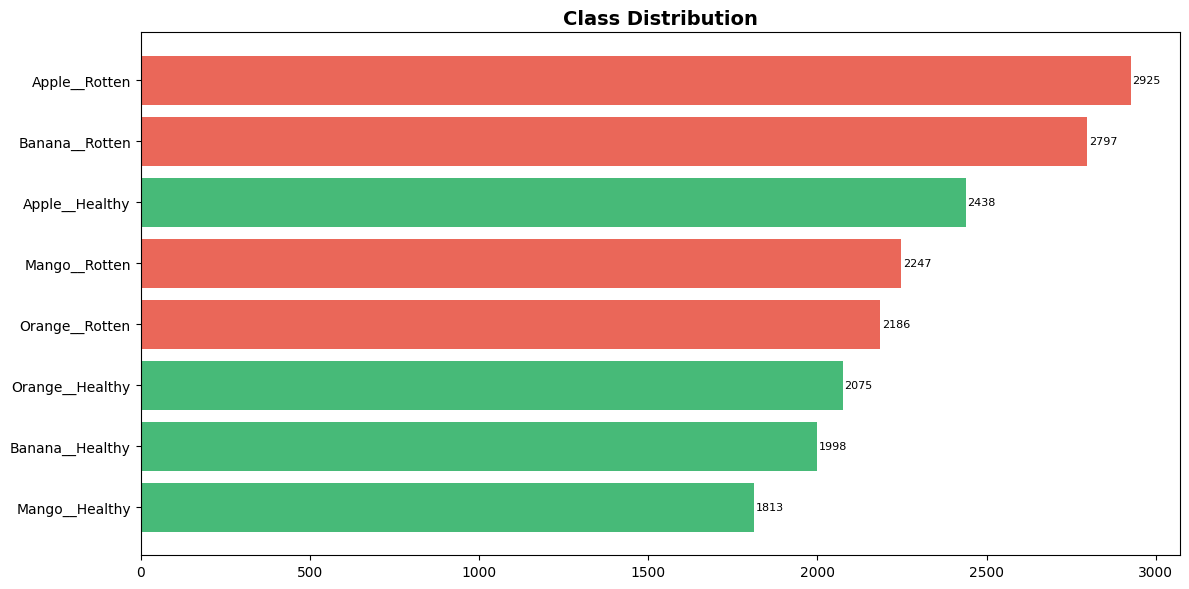

In [16]:
# ===== SELECTED CLASSES =====
SELECTED_CLASSES = [
    'Apple__Healthy',
    'Apple__Rotten',
    'Banana__Healthy',
    'Banana__Rotten',
    'Orange__Healthy',
    'Orange__Rotten',
    'Mango__Healthy',
    'Mango__Rotten',
]

# ===== CREATE FILTERED DATASET =====
FILTERED_DIR = Path('/kaggle/working/filtered_dataset')

if FILTERED_DIR.exists():
    shutil.rmtree(FILTERED_DIR)

FILTERED_DIR.mkdir(parents=True)

for cls in SELECTED_CLASSES:
    src = TRAIN_DIR / cls
    dst = FILTERED_DIR / cls
    if src.exists():
        shutil.copytree(src, dst)
    else:
        print(f'WARNING: class folder not found: {src}')

# ===== SCAN & REMOVE CORRUPT FILES (PIL + TF double-check) =====
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
bad_files = []

for path in FILTERED_DIR.rglob('*'):
    if not path.is_file():
        continue
    if path.suffix.lower() not in VALID_EXTS:
        bad_files.append(path)
        continue
    # PIL check
    try:
        with PILImage.open(path) as img:
            img.verify()
        with PILImage.open(path) as img:
            img.load()
    except Exception:
        bad_files.append(path)
        continue
    # TF check
    try:
        raw = tf.io.read_file(str(path))
        tf.image.decode_image(raw, channels=3)
    except Exception:
        bad_files.append(path)

print(f'Corrupt / unreadable files found: {len(bad_files)}')
for p in bad_files:
    print(f'  REMOVING: {p}')
    p.unlink()
print('Done.')

# ===== CLASS DISTRIBUTION =====
class_counts = {}
for cls_dir in sorted(FILTERED_DIR.iterdir()):
    if cls_dir.is_dir():
        imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXTS]
        class_counts[cls_dir.name] = len(imgs)

df_counts = pd.DataFrame(
    list(class_counts.items()), columns=['class', 'count']
).sort_values('count')

CLASS_NAMES = sorted(class_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)
TOTAL_IMGS  = df_counts['count'].sum()

print(f'Classes: {NUM_CLASSES}')
print(f'Total images: {TOTAL_IMGS:,}')
print(df_counts)

# ===== PLOT =====
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if 'rotten' in c.lower() else '#27ae60' for c in df_counts['class']]
ax.barh(df_counts['class'], df_counts['count'], color=colors, alpha=0.85)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(df_counts['count']):
    ax.text(v + 5, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Corrupt-file scan already done in the dataset-creation cell above.

In [17]:
# Removal already handled in the dataset-creation cell above.

Removed bad files.


## 3. tf.data Pipeline

> We use `tf.data` instead of the legacy `ImageDataGenerator`. It is ~2x faster on GPU because it prefetches batches on CPU while the GPU trains. On a 5GB dataset this matters a lot.

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

# Discover classes from FILTERED_DIR (already cleaned)
CLASS_NAMES = sorted([
    d.name for d in FILTERED_DIR.iterdir()
    if d.is_dir() and not d.name.startswith('.')
])
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# Build clean path/label lists from the already-scanned directory
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
valid_paths, valid_labels = [], []

for cls_name in CLASS_NAMES:
    cls_dir = FILTERED_DIR / cls_name
    label   = class_to_idx[cls_name]
    for p in cls_dir.iterdir():
        if p.suffix.lower() in VALID_EXTS:
            valid_paths.append(str(p))
            valid_labels.append(label)

print(f'Total valid images: {len(valid_paths):,}')

# Shuffle & split
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(valid_paths))
valid_paths  = np.array(valid_paths)[idx].tolist()
valid_labels = np.array(valid_labels)[idx].tolist()

n_total = len(valid_paths)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val - n_test
print(f'Total: {n_total} -> Train: {n_train} | Val: {n_val} | Test: {n_test}')

# Safe loader: returns ok=False sentinel on TF decode failure
def safe_load_image(path, label):
    def _load(p, l):
        try:
            raw   = tf.io.read_file(p.numpy().decode())
            image = tf.image.decode_image(raw, channels=3, expand_animations=False)
            image = tf.image.resize(image, IMG_SIZE)
            image = tf.cast(image, tf.float32)
            onehot = tf.one_hot(int(l.numpy()), NUM_CLASSES)
            return image, onehot, tf.constant(True)
        except Exception:
            dummy  = tf.zeros([IMG_SIZE[0], IMG_SIZE[1], 3], dtype=tf.float32)
            onehot = tf.zeros([NUM_CLASSES], dtype=tf.float32)
            return dummy, onehot, tf.constant(False)

    image, onehot, ok = tf.py_function(
        func=_load, inp=[path, label],
        Tout=[tf.float32, tf.float32, tf.bool]
    )
    image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    onehot.set_shape([NUM_CLASSES])
    ok.set_shape([])
    return image, onehot, ok

def make_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(safe_load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda img, lbl, ok: ok)
    ds = ds.map(lambda img, lbl, ok: (img, lbl))
    return ds

train_paths  = valid_paths[:n_train]
train_labels = valid_labels[:n_train]
val_paths    = valid_paths[n_train:n_train + n_val]
val_labels   = valid_labels[n_train:n_train + n_val]
test_paths   = valid_paths[n_train + n_val:]
test_labels  = valid_labels[n_train + n_val:]

train_ds = make_ds(train_paths, train_labels)
val_ds   = make_ds(val_paths,   val_labels)
test_ds  = make_ds(test_paths,  test_labels)

print('Datasets created successfully.')

Classes (8): ['Apple__Healthy', 'Apple__Rotten', 'Banana__Healthy', 'Banana__Rotten', 'Mango__Healthy', 'Mango__Rotten', 'Orange__Healthy', 'Orange__Rotten']
Total valid images: 18,479
Total: 18479 -> Train: 12937 | Val: 3695 | Test: 1847
Datasets created successfully.


In [18]:
# GPU-accelerated augmentation layers
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
], name='augmentation')

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = augmentation(image, training=True)
    return resnet_preprocess(image), label

def preprocess_eval(image, label):
    image = tf.cast(image, tf.float32)
    return resnet_preprocess(image), label

train_pipeline = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
val_pipeline   = val_ds.map(preprocess_eval,    num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
test_pipeline  = test_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
print('Pipelines ready.')

Pipelines ready.


## 4. Class Weights

In [19]:
# Use train_labels (already filtered to valid images only) for accurate counts
cw_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
CLASS_WEIGHTS = dict(enumerate(cw_arr))
print('Class weights (most imbalanced):')
for idx, w in sorted(CLASS_WEIGHTS.items(), key=lambda x: -x[1])[:6]:
    print(f'  [{idx:2d}] {CLASS_NAMES[idx]:35s} -> {w:.3f}')

Class weights (most imbalanced):
  [ 4] Mango__Healthy                      -> 1.241
  [ 2] Banana__Healthy                     -> 1.175
  [ 6] Orange__Healthy                     -> 1.128
  [ 7] Orange__Rotten                      -> 1.080
  [ 5] Mango__Rotten                       -> 1.015
  [ 0] Apple__Healthy                      -> 0.936


## 5. Model — ResNet50V2

**Why EfficientNetV2S?**
- 83.9% ImageNet top-1 vs ResNet50 76.0% / MobileNetV2 71.8%
- Faster to train than ResNet50 at equal accuracy
- ~20M params, fits on T4 with mixed_float16
- Built-in preprocessing (`include_preprocessing=True`)

In [21]:
def build_model(num_classes, unfreeze_layers=0):
    backbone = ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3)
    )
    backbone.trainable = False

    if unfreeze_layers > 0:
        for layer in backbone.layers[-unfreeze_layers:]:
            if not isinstance(layer, layers.BatchNormalization):
                layer.trainable = True

    trainable = sum(1 for l in backbone.layers if l.trainable)
    print(f'Backbone layers: {len(backbone.layers)} | Trainable: {trainable}')

    inputs  = keras.Input(shape=(*IMG_SIZE, 3), name='image_input')
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, name='fc1')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Activation('relu', name='relu_head')(x)
    x = layers.Dropout(0.4, name='dropout_head')(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)
    return keras.Model(inputs, outputs, name=f'{MODEL_NAME}_Classifier')

model = build_model(NUM_CLASSES)
model.summary(expand_nested=False)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone layers: 190 | Trainable: 0


Model: "ResNet50V2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_head (Activation)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,620,040 (93.92 MB)

 Trainable params: 1,054,216 (4.02 MB)

 Non-trainable params: 23,565,824 (89.90 MB)

## 6. Phase 1 — Feature Extraction (Backbone Frozen)

In [24]:
steps_per_epoch = n_train // BATCH

model.compile(
    optimizer=optimizers.AdamW(learning_rate=LR_FE, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_fe = [
    callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_fe.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.CSVLogger(str(MODEL_DIR / 'history_fe.csv'))
]

print(f'Phase 1: Feature Extraction — up to {EPOCHS_FE} epochs')
history_fe = model.fit(
    train_pipeline, validation_data=val_pipeline,
    epochs=EPOCHS_FE, class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_fe, verbose=1
)

Phase 1: Feature Extraction — up to 10 epochs
Epoch 1/10
    405/Unknown 104s 225ms/step - accuracy: 0.8975 - loss: 0.2891 - top3_acc: 0.9910
Epoch 1: val_accuracy improved from -inf to 0.92666, saving model to /kaggle/working/models/best_fe.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 132s 292ms/step - accuracy: 0.8975 - loss: 0.2891 - top3_acc: 0.9910 - val_accuracy: 0.9267 - val_loss: 0.2054 - val_top3_acc: 0.9954 - learning_rate: 0.0010
Epoch 2/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9137 - loss: 0.2523 - top3_acc: 0.9933
Epoch 2: val_accuracy improved from 0.92666 to 0.93775, saving model to /kaggle/working/models/best_fe.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 105s 260ms/step - accuracy: 0.9138 - loss: 0.2523 - top3_acc: 0.9933 - val_accuracy: 0.9378 - val_loss: 0.1832 - val_top3_acc: 0.9965 - learning_rate: 0.0010
Epoch 3/10
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9238 - loss: 0.2099 - top3_acc: 0.9953
Epoch 3: val_accuracy improved from 0.93775 to 0.94317,

## 7. Phase 2 — Fine-Tuning

In [26]:
print(f'Unfreezing last {UNFREEZE} backbone layers...')
model_ft = build_model(NUM_CLASSES, unfreeze_layers=UNFREEZE)
model_ft.set_weights(model.get_weights())

lr_schedule_ft = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_FT,
    decay_steps=steps_per_epoch * EPOCHS_FT,
    alpha=1e-7
)

model_ft.compile(
    optimizer=optimizers.AdamW(learning_rate=lr_schedule_ft, weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_ft = [
    callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_ft.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    callbacks.CSVLogger(str(MODEL_DIR / 'history_ft.csv'))
]

print(f'Phase 2: Fine-Tuning — up to {EPOCHS_FT} epochs')
history_ft = model_ft.fit(
    train_pipeline, validation_data=val_pipeline,
    epochs=EPOCHS_FT, class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_ft, verbose=1
)

Unfreezing last 30 backbone layers...
Backbone layers: 190 | Trainable: 22
Phase 2: Fine-Tuning — up to 6 epochs
Epoch 1/6
    405/Unknown 109s 230ms/step - accuracy: 0.9578 - loss: 0.1205 - top3_acc: 0.9990
Epoch 1: val_accuracy improved from -inf to 0.96401, saving model to /kaggle/working/models/best_ft.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 133s 291ms/step - accuracy: 0.9578 - loss: 0.1205 - top3_acc: 0.9990 - val_accuracy: 0.9640 - val_loss: 0.0997 - val_top3_acc: 0.9978
Epoch 2/6
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9655 - loss: 0.0950 - top3_acc: 0.9987
Epoch 2: val_accuracy improved from 0.96401 to 0.97185, saving model to /kaggle/working/models/best_ft.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 106s 262ms/step - accuracy: 0.9655 - loss: 0.0950 - top3_acc: 0.9987 - val_accuracy: 0.9719 - val_loss: 0.0858 - val_top3_acc: 0.9981
Epoch 3/6
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9734 - loss: 0.0800 - top3_acc: 0.9994
Epoch 3: val_accuracy improved from 0.9

## 8. Training Curves

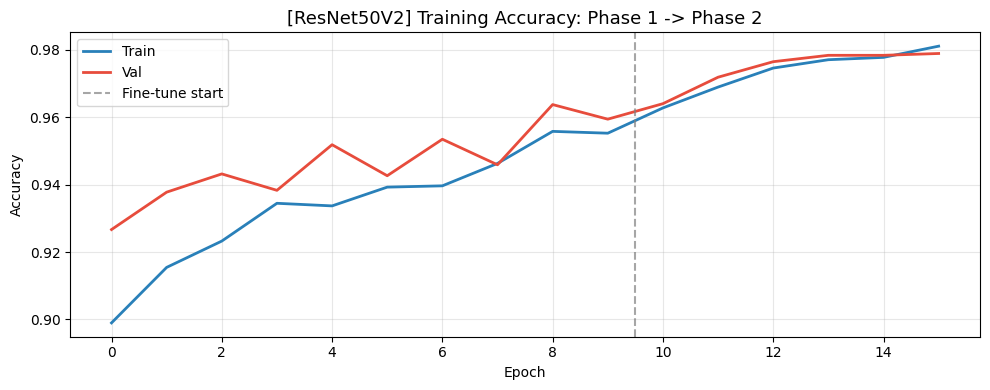

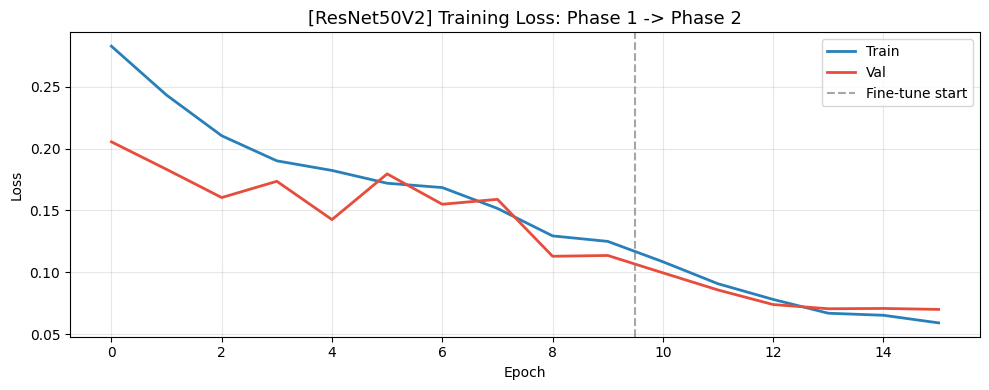

In [27]:
def plot_combined(h_fe, h_ft, model_name):
    fe_len = len(h_fe.history['accuracy'])
    for metric, ylabel in [('accuracy','Accuracy'), ('loss','Loss')]:
        train = h_fe.history[metric] + h_ft.history[metric]
        val   = h_fe.history[f'val_{metric}'] + h_ft.history[f'val_{metric}']
        plt.figure(figsize=(10, 4))
        plt.plot(train, label='Train', color='#2980b9', lw=2)
        plt.plot(val,   label='Val',   color='#e74c3c', lw=2)
        plt.axvline(fe_len - 0.5, color='gray', ls='--', alpha=0.7, label='Fine-tune start')
        plt.xlabel('Epoch'); plt.ylabel(ylabel); plt.legend(); plt.grid(alpha=0.3)
        plt.title(f'[{model_name}] Training {ylabel}: Phase 1 -> Phase 2', fontsize=13)
        plt.tight_layout(); plt.show()

plot_combined(history_fe, history_ft, MODEL_NAME)

## 9. Evaluation

In [28]:
best_model = keras.models.load_model(str(MODEL_DIR / 'best_ft.keras'))
test_loss, test_acc, test_top3 = best_model.evaluate(test_pipeline, verbose=1)
print(f'\n[{MODEL_NAME}] Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'[{MODEL_NAME}] Test Top-3 Accuracy: {test_top3:.4f} ({test_top3*100:.2f}%)')
print(f'[{MODEL_NAME}] Test Loss:           {test_loss:.4f}')

58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 234ms/step - accuracy: 0.9715 - loss: 0.0746 - top3_acc: 0.9974

[ResNet50V2] Test Accuracy:       0.9756 (97.56%)
[ResNet50V2] Test Top-3 Accuracy: 0.9984 (99.84%)
[ResNet50V2] Test Loss:           0.0735


                 precision    recall  f1-score   support

 Apple__Healthy      0.972     0.976     0.974       245
  Apple__Rotten      0.978     0.957     0.967       278
Banana__Healthy      0.986     0.990     0.988       207
 Banana__Rotten      0.996     0.989     0.992       265
 Mango__Healthy      0.971     0.960     0.965       174
  Mango__Rotten      0.975     0.983     0.979       238
Orange__Healthy      0.958     0.986     0.971       207
 Orange__Rotten      0.966     0.966     0.966       233

       accuracy                          0.976      1847
      macro avg      0.975     0.976     0.975      1847
   weighted avg      0.976     0.976     0.976      1847



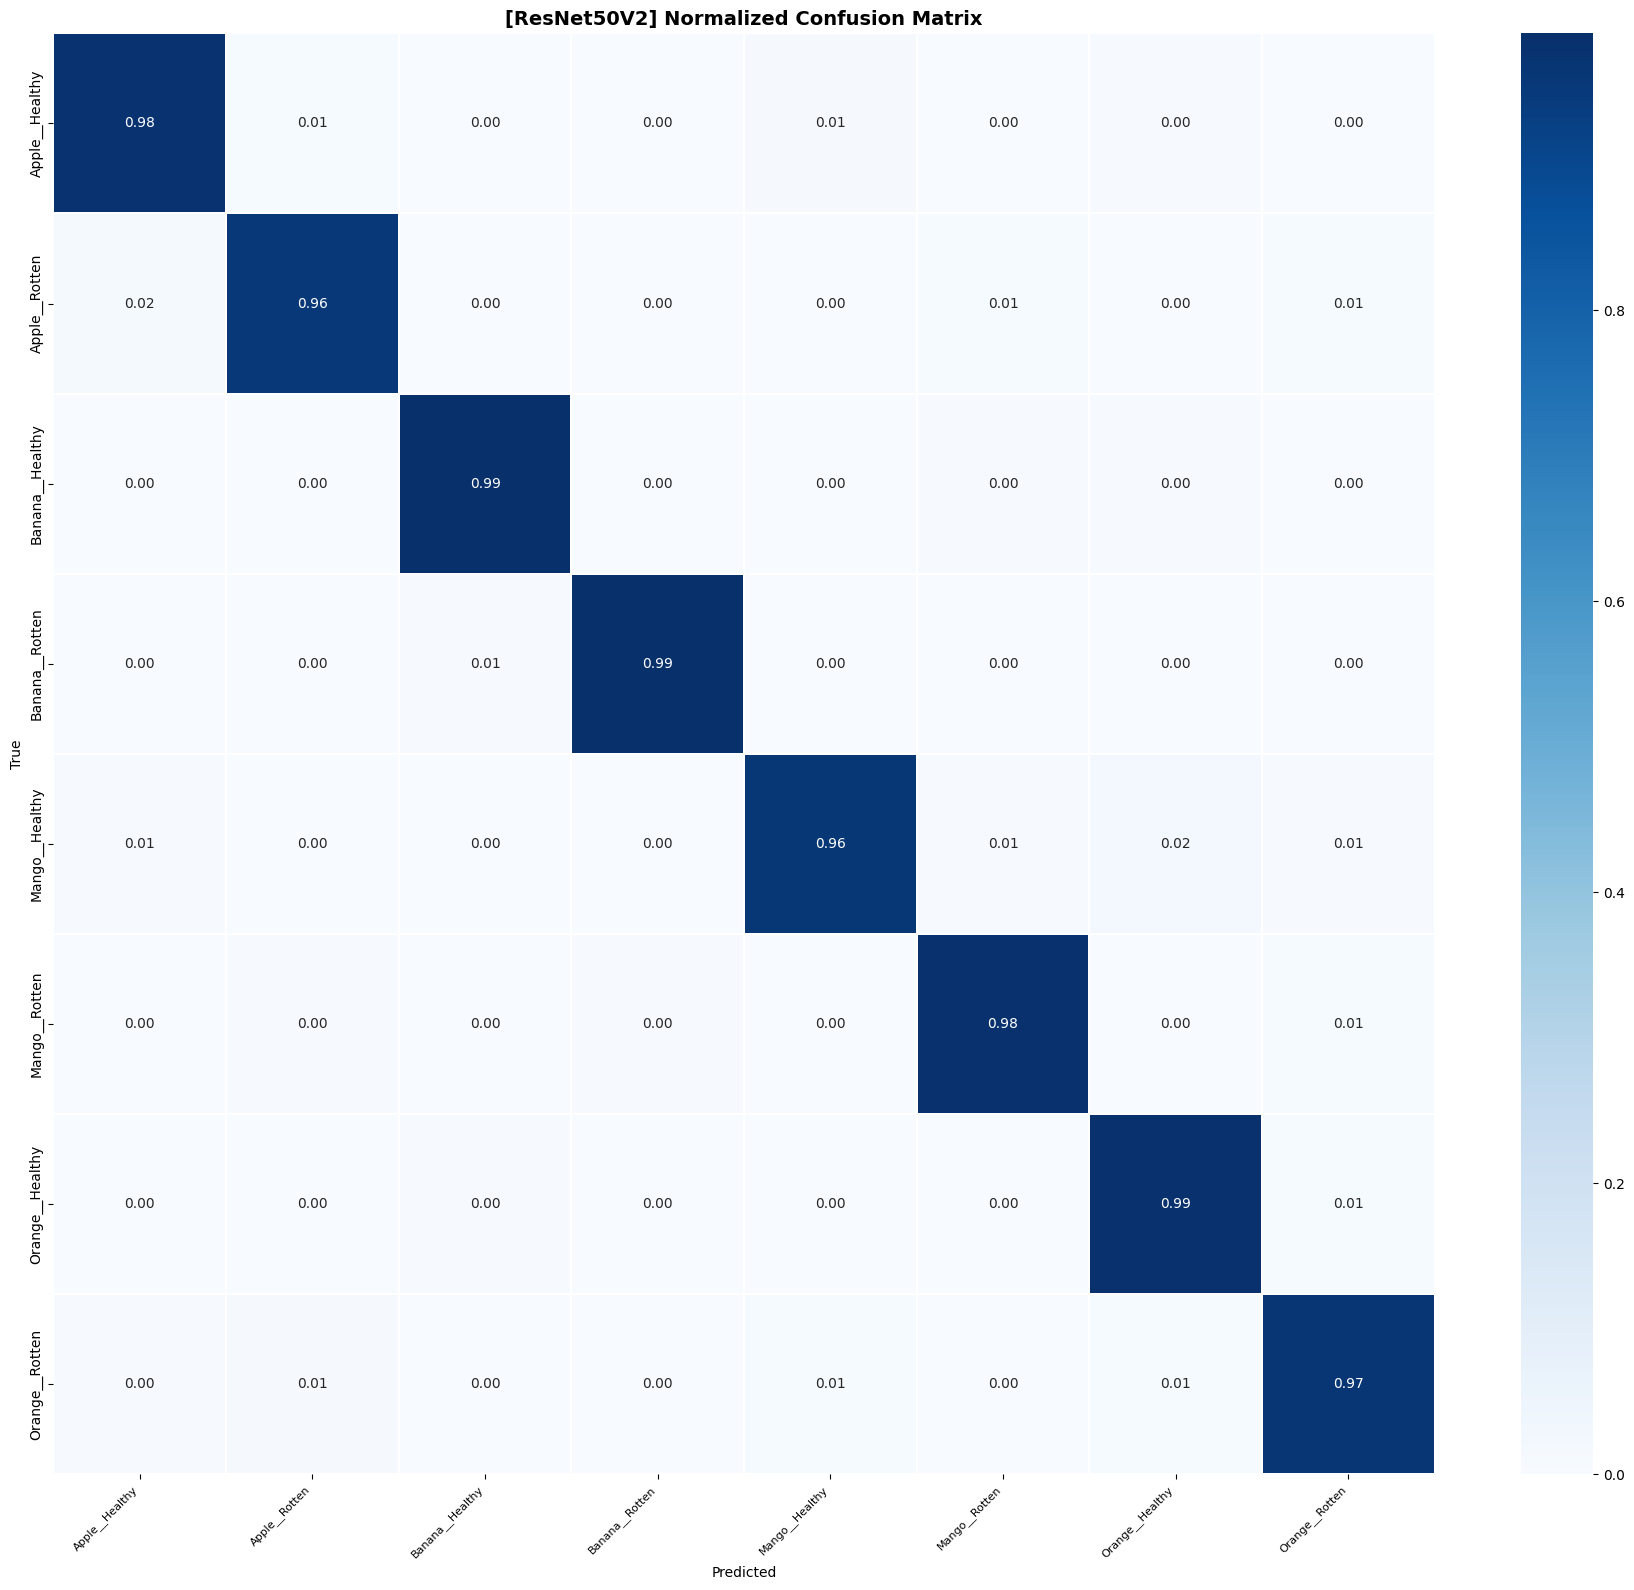

In [30]:
y_true, y_pred = [], []
for images, labels in test_pipeline:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

cm_m  = confusion_matrix(y_true, y_pred)
cm_n  = cm_m.astype('float') / cm_m.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'[{MODEL_NAME}] Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

## 10. Grad-CAM

Shows where the model looks when predicting. Important for validating that the model focuses on actual rot/disease areas and not the background.

In [31]:
best_model.save(str(MODEL_DIR / f'{MODEL_NAME.lower()}.keras'))
print(f'Saved: {MODEL_NAME.lower()}.keras')

meta = {
    'model_name': MODEL_NAME,
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': list(IMG_SIZE),
    'test_accuracy': float(test_acc),
    'test_top3_accuracy': float(test_top3),
    'test_loss': float(test_loss)
}
with open(str(MODEL_DIR / 'results.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('\n========= RESULTS SUMMARY =========')
print(f'  Model:          {MODEL_NAME}')
print(f'  Test Accuracy:  {test_acc*100:.2f}%')
print(f'  Top-3 Accuracy: {test_top3*100:.2f}%')
print(f'  Test Loss:      {test_loss:.4f}')
print('===================================')
print('Compare this against EfficientNetV2S, MobileNetV3Large, and ConvNeXtTiny results.')

Saved: resnet50v2.keras

========= RESULTS SUMMARY =========
  Model:          ResNet50V2
  Test Accuracy:  97.56%
  Top-3 Accuracy: 99.84%
  Test Loss:      0.0735
Compare this against EfficientNetV2S, MobileNetV3Large, and ConvNeXtTiny results.


Saving model

In [32]:
history_data = {
    "phase1": history_fe.history,
    "phase2": history_ft.history
}

with open(str(MODEL_DIR / f'{MODEL_NAME.lower()}_history.json'), 'w') as f:
    json.dump(history_data, f)

print("History saved.")

History saved.
